In [1]:
import numpy as np
import pandas as pd
import pywt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import f
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends import backend_pdf
from Interval_Halving import Modified_Interval_Halving

In [2]:
location = 'Altitude_data.xlsx'
sheet_to_df_map = pd.read_excel(location, sheet_name = None)

## Parameter Tuning for Noise Fraction

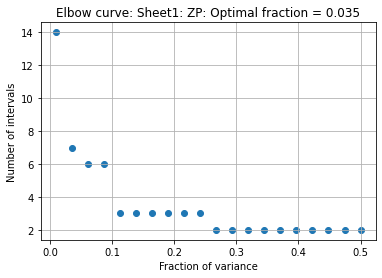

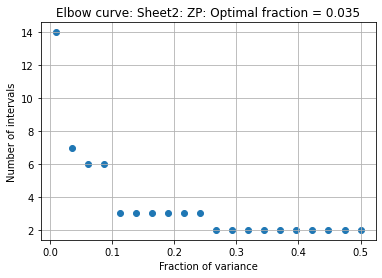

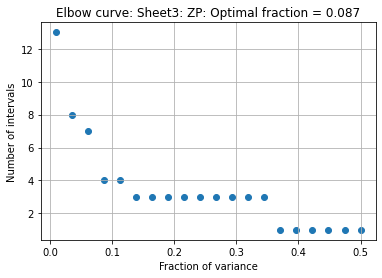

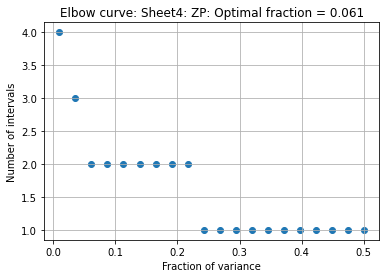

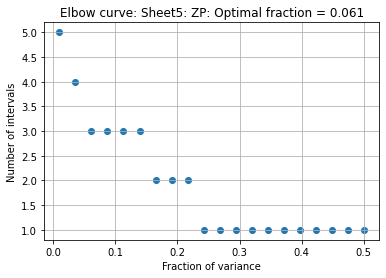

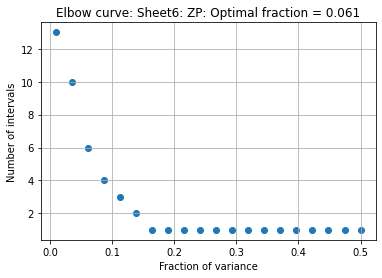

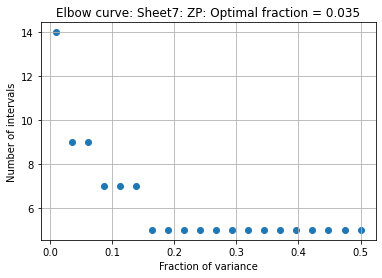

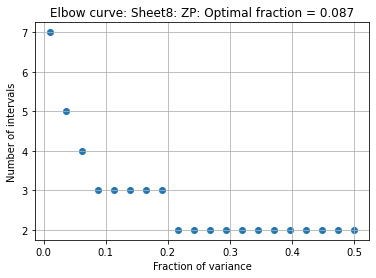

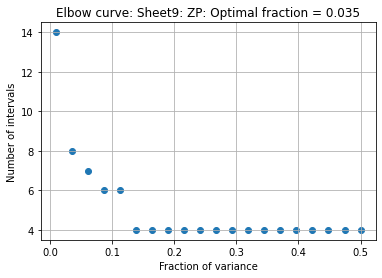

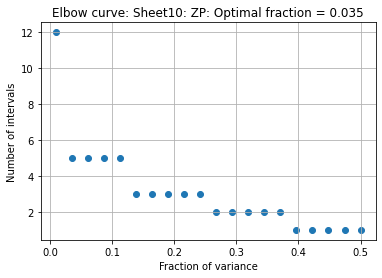

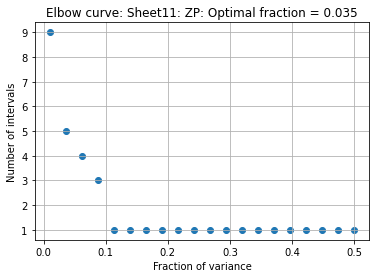

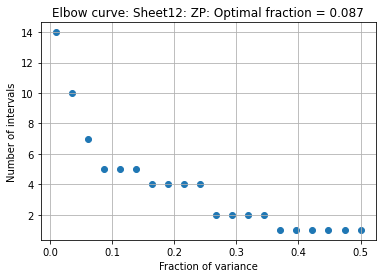

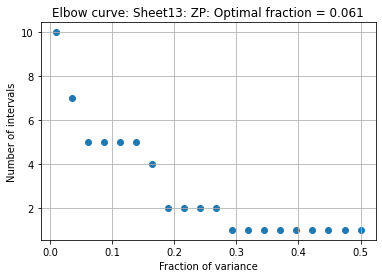

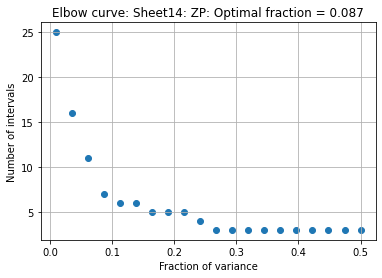

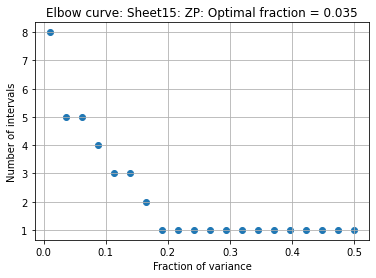

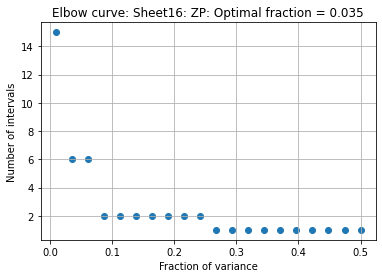

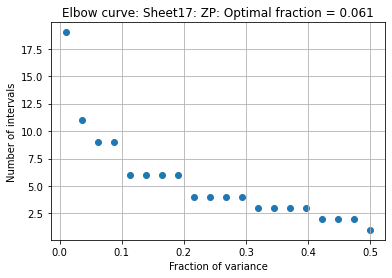

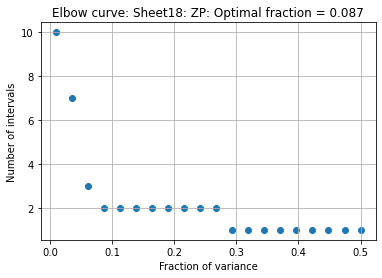

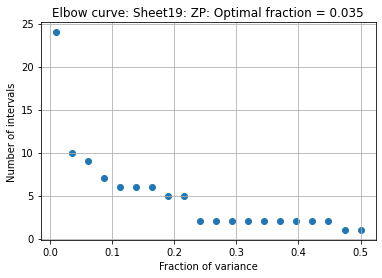

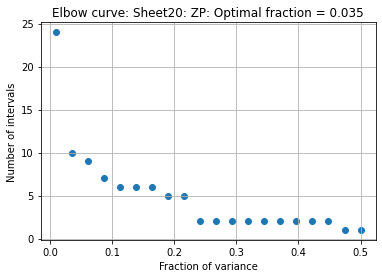

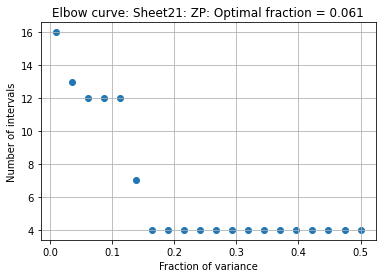

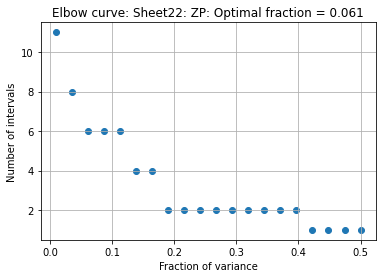

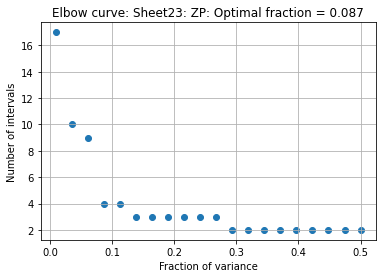

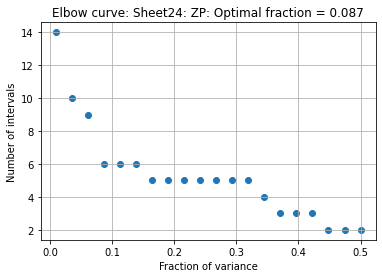

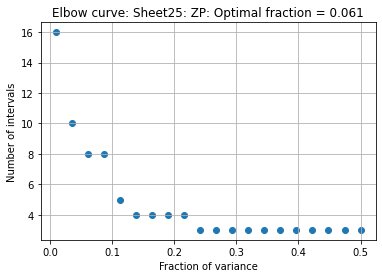

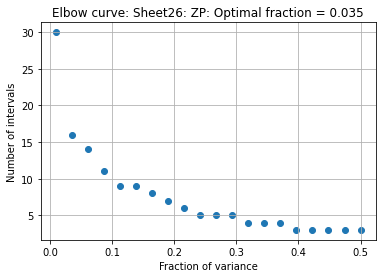

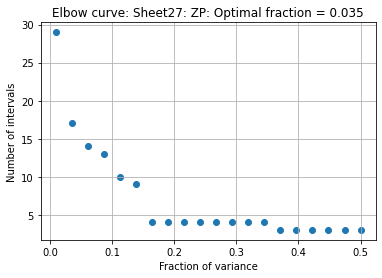

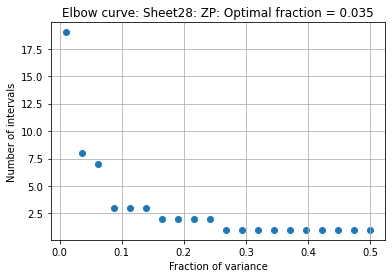

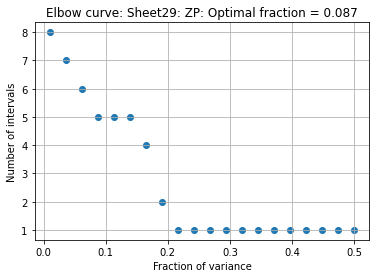

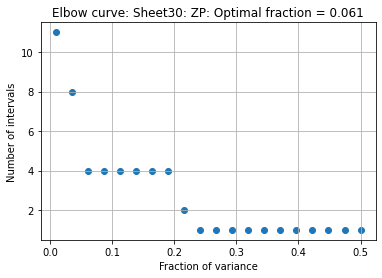

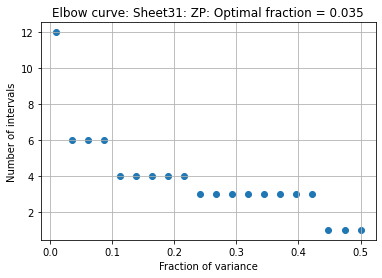

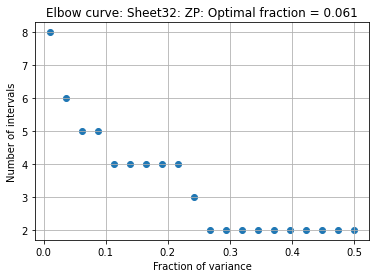

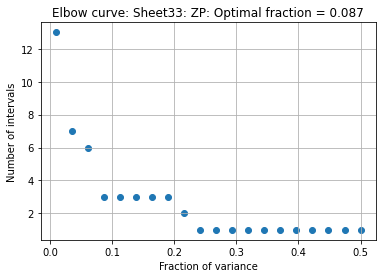

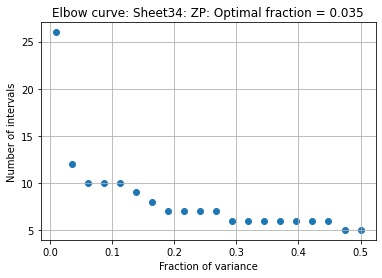

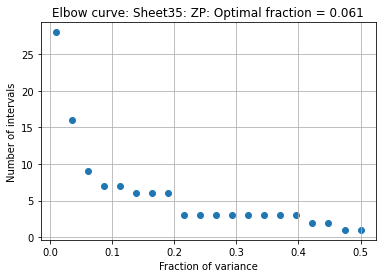

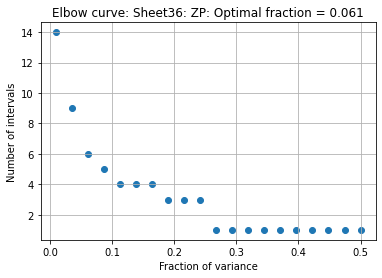

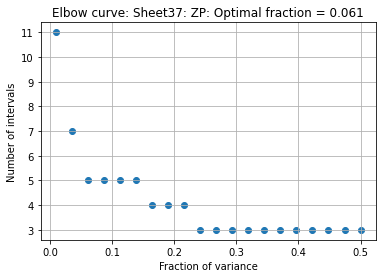

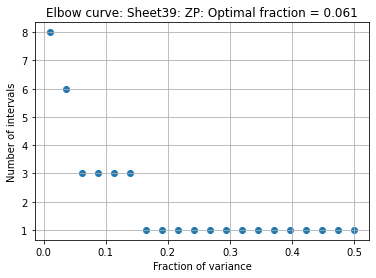

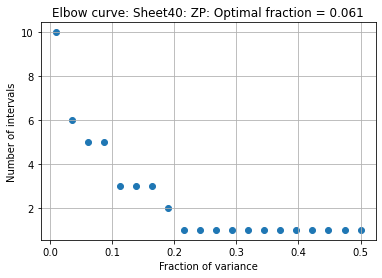

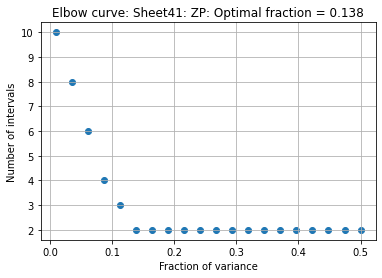

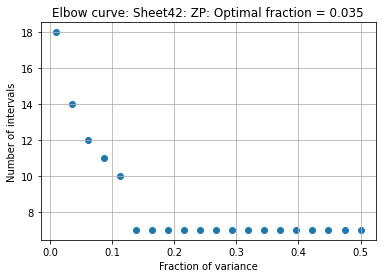

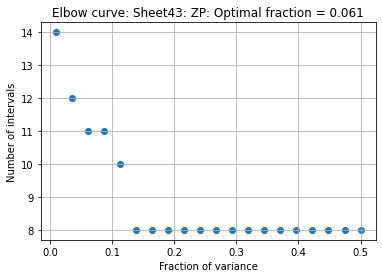

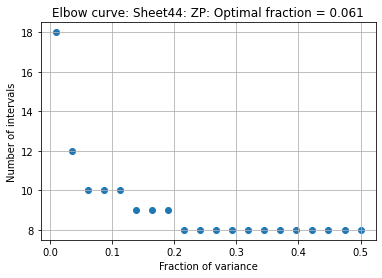

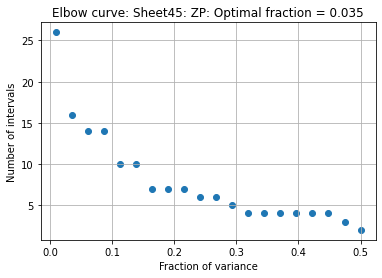

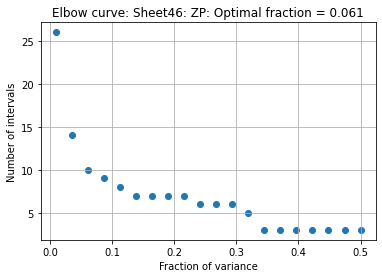

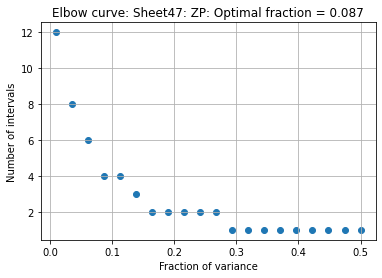

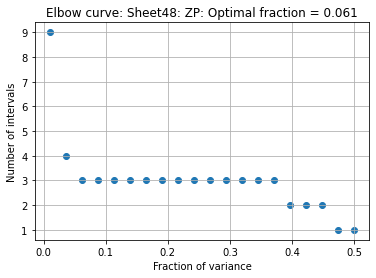

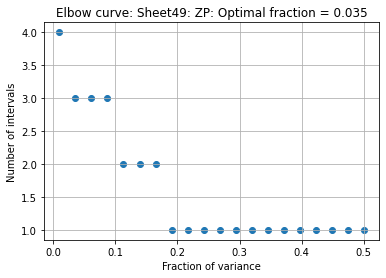

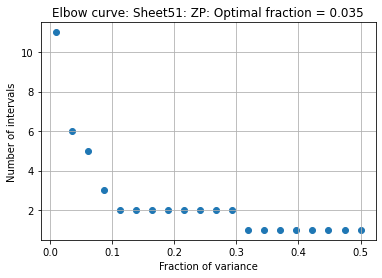

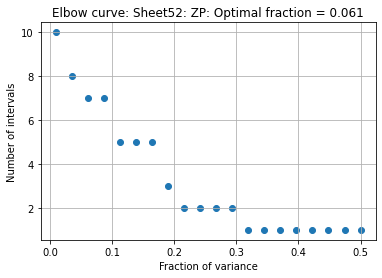

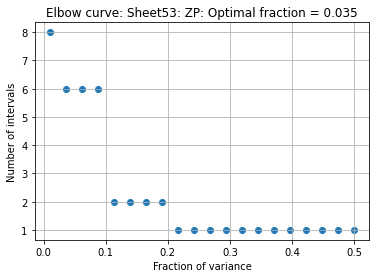

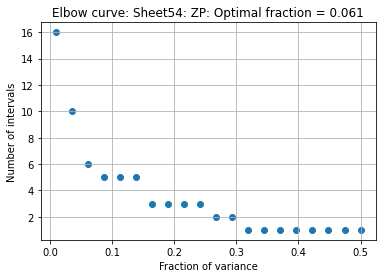

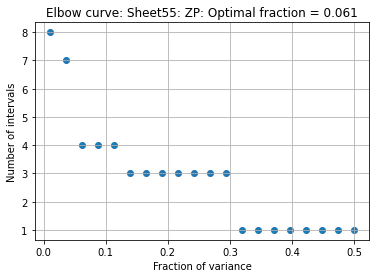

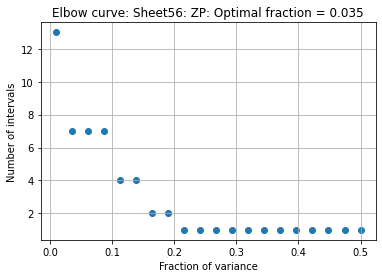

In [3]:
col_names = ['ZP']
var_fracs = np.linspace(0.01, 0.5, 20)

# Optimal parameter values obtained manually by observing the plots
frac_zp = [0.035, 0.035, 0.087, 0.061, 0.061, 0.061, 0.035, 0.087, 0.035, 0.035, 0.035, 0.087, 0.061, 0.087, 0.035, \
           0.035, 0.061, 0.087, 0.035, 0.035, 0.061, 0.061, 0.087, 0.087, 0.061, 0.035, 0.035, 0.035, 0.087, 0.061, \
           0.035, 0.061, 0.087, 0.035, 0.061, 0.061, 0.061, 0.061, 0.061, 0.061, 0.138, 0.035, 0.061, 0.061, 0.035, \
           0.061, 0.087, 0.061, 0.035, 0.035, 0.035, 0.061, 0.035, 0.061, 0.061, 0.035]

opt_fracs = {'ZP': frac_zp}

for sheet_ind, sheet_name in enumerate(sheet_to_df_map):
    if sheet_ind == 37 or sheet_ind == 49: # Data for these project IDs is missing
        continue
    df = sheet_to_df_map[sheet_name]
    for col in col_names:
        process_data = df[col].dropna().to_numpy()
        len_data = process_data.shape[0]
        err_data = np.var(process_data)
        count_segments = np.zeros((20,))
        for ind_frac, frac in enumerate(var_fracs):
            model = Modified_Interval_Halving(noise_err = frac*err_data, min_window_len = 100, \
                                             title = str(sheet_name + ": " + col), suppress_print = True)

            count_segments[ind_frac] = model.train_model(process_data)
            
        fig_temp = plt.figure()
        plt.title('Elbow curve: {}: {}: Optimal fraction = {}'.format(sheet_name, col, opt_fracs[col][sheet_ind]))
        plt.scatter(var_fracs, count_segments)
        plt.xlabel('Fraction of variance')
        plt.ylabel('Number of intervals')
        plt.grid()
        plt.show()

## Parameter Tuning for Minimum Window Length

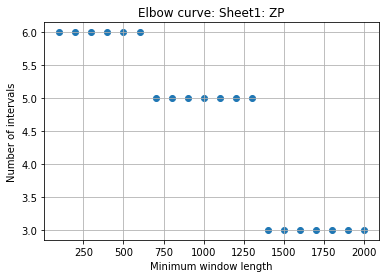

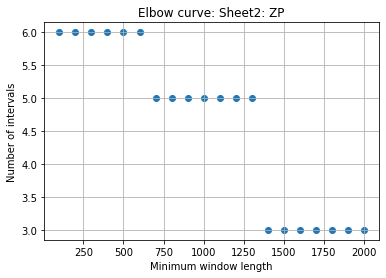

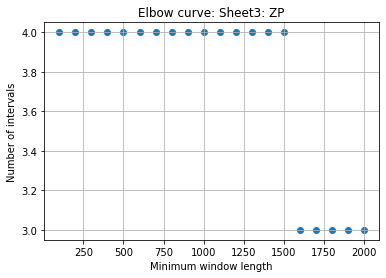

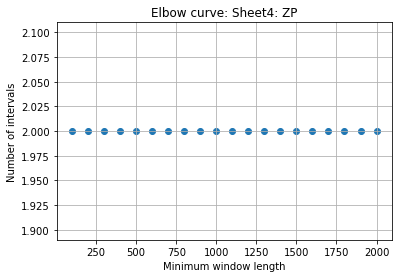

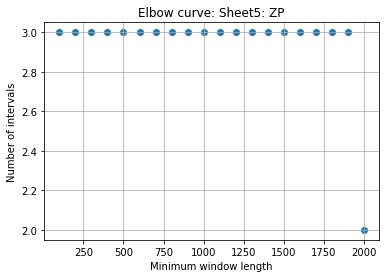

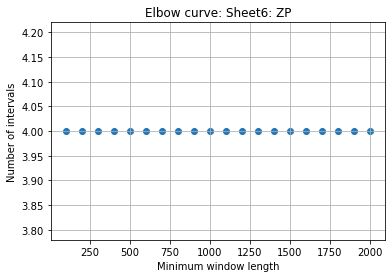

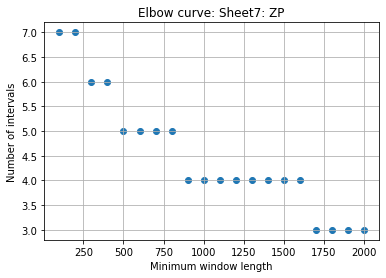

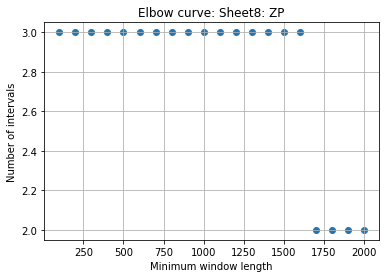

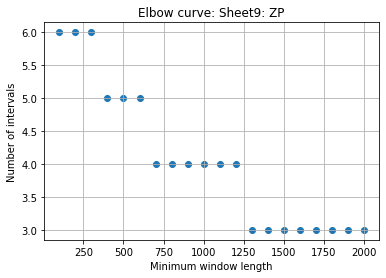

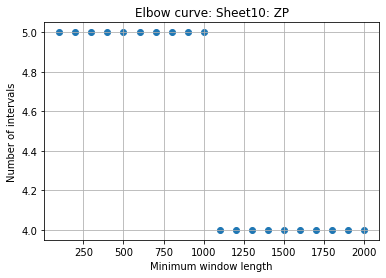

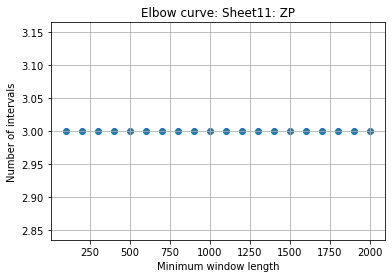

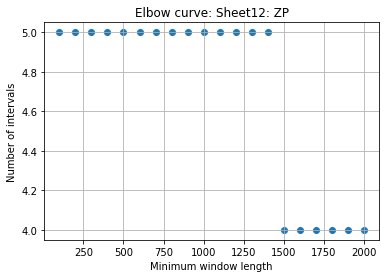

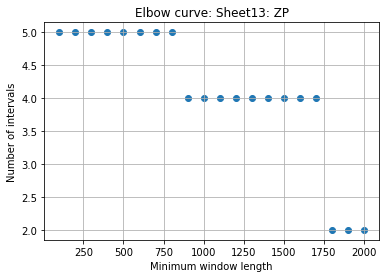

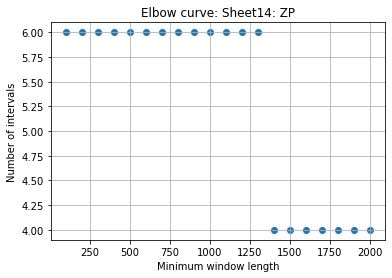

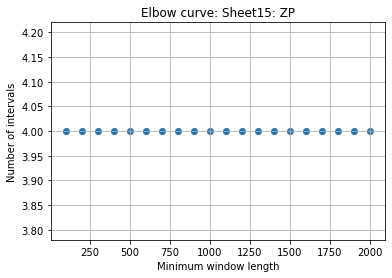

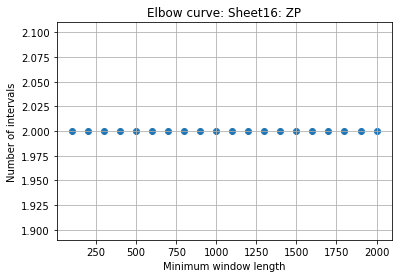

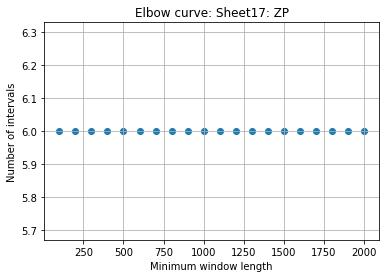

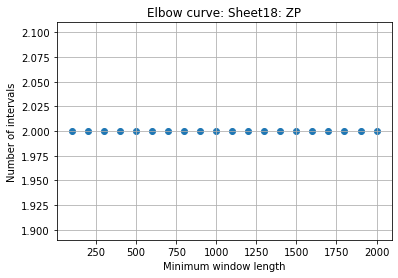

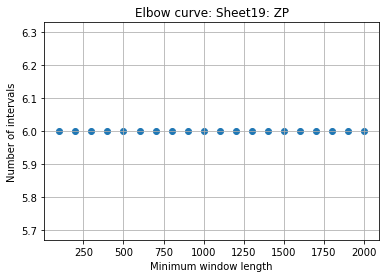

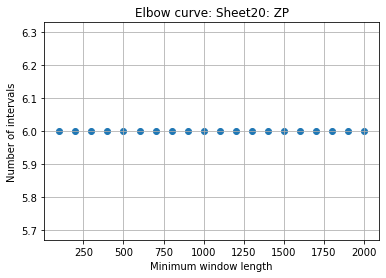

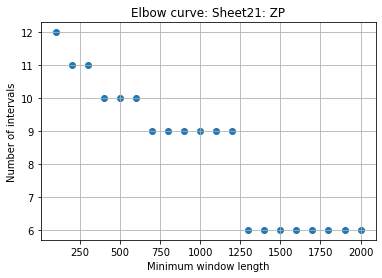

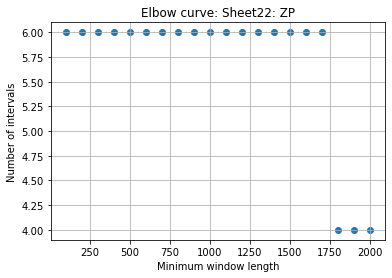

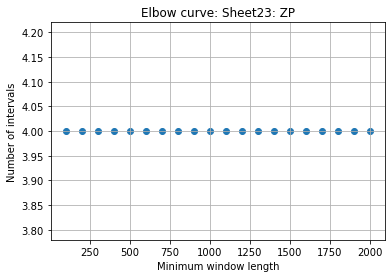

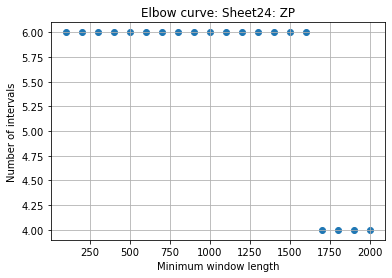

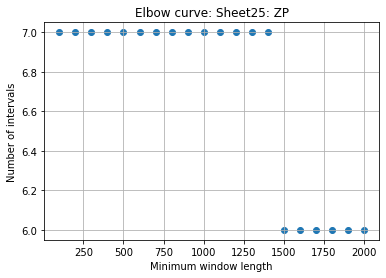

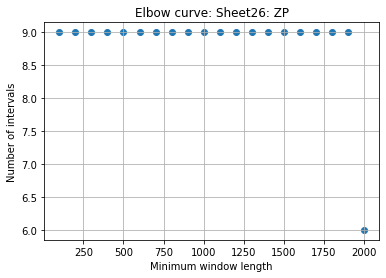

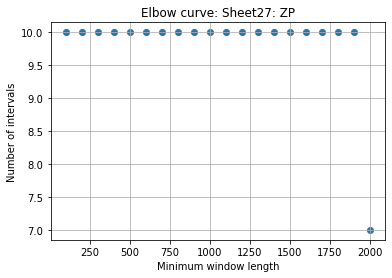

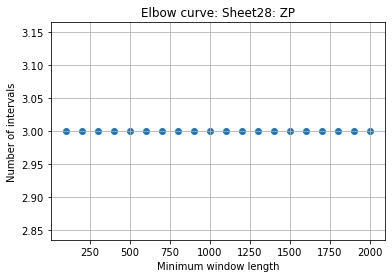

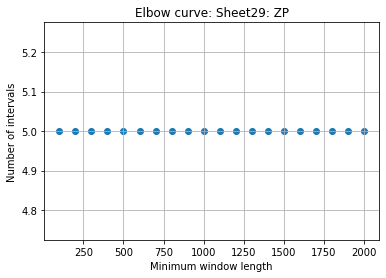

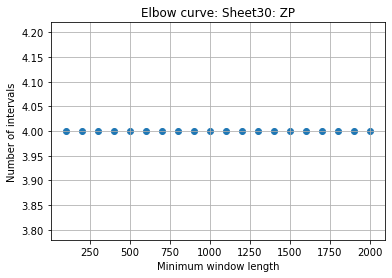

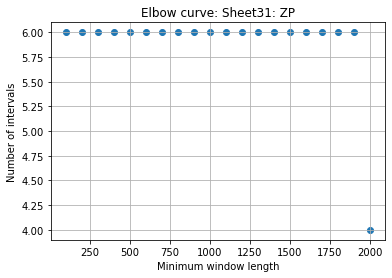

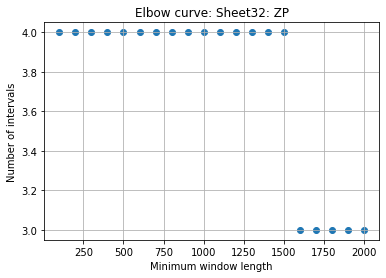

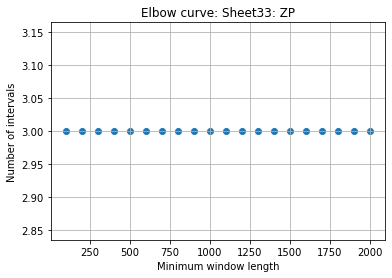

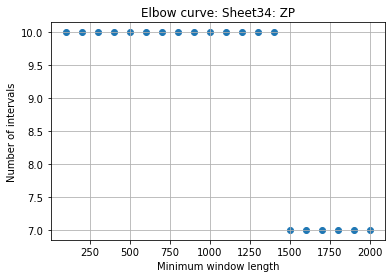

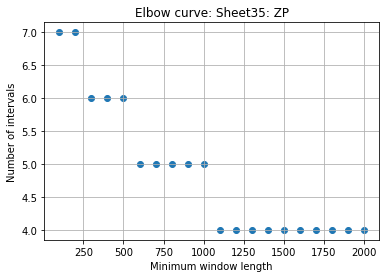

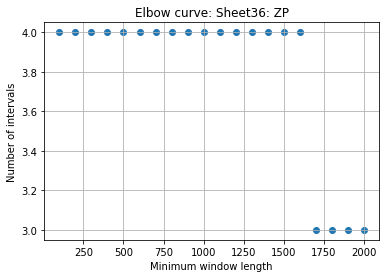

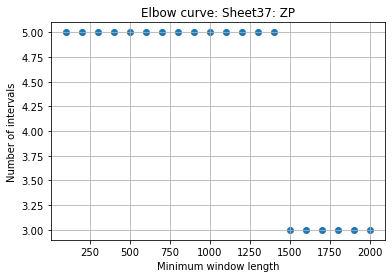

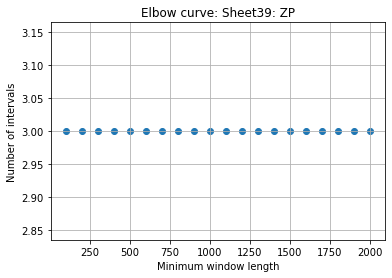

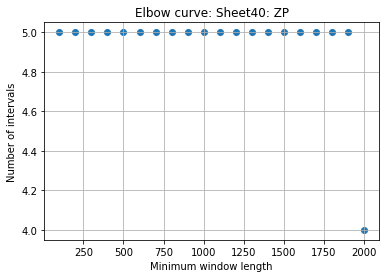

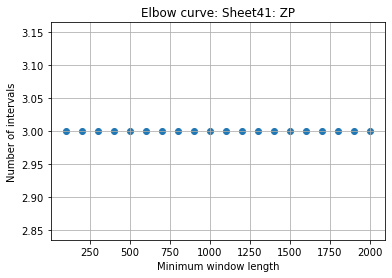

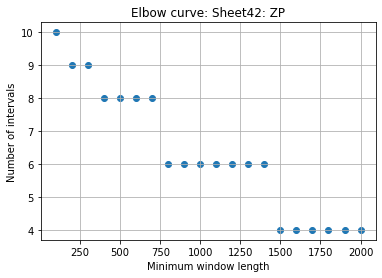

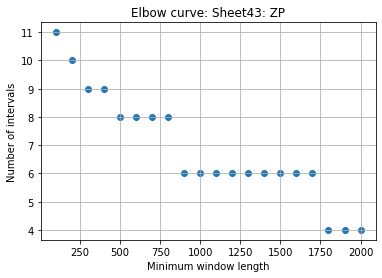

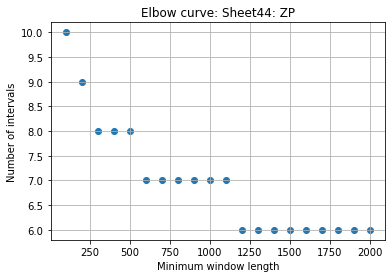

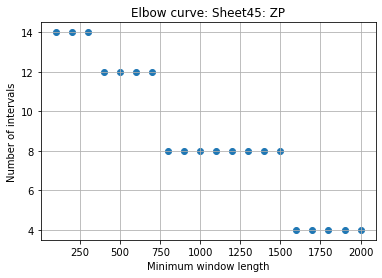

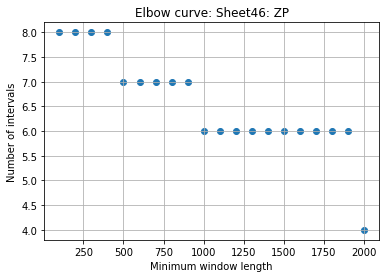

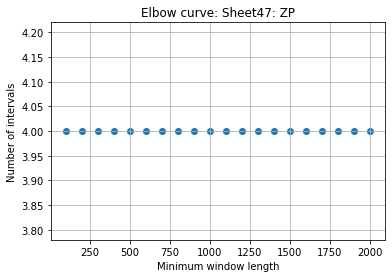

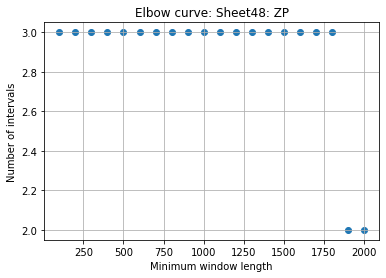

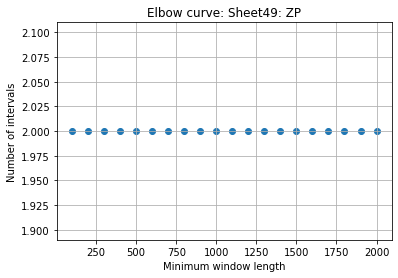

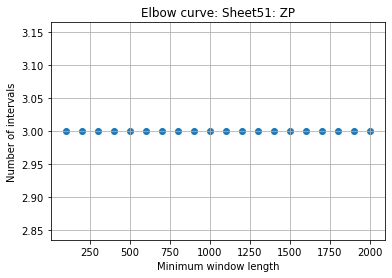

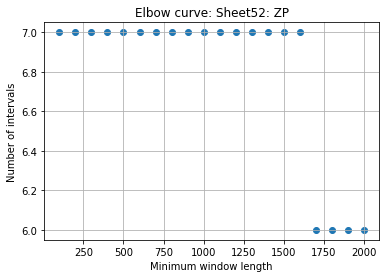

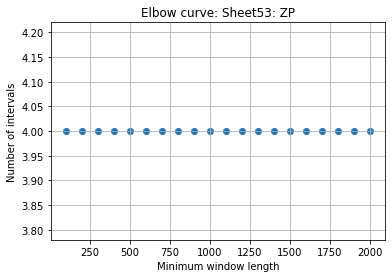

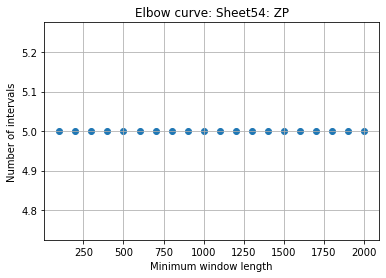

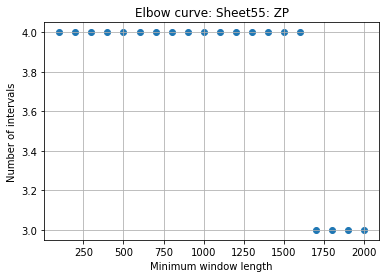

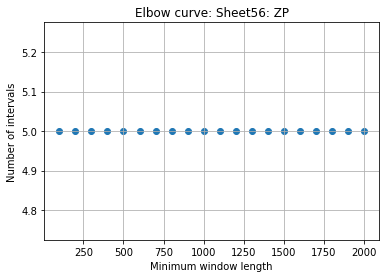

In [5]:
# Min window length = 100 seems optimal for most of the time series
col_names = ['ZP']
window_lens_tuning = np.linspace(100, 2000, 20)
for sheet_ind, sheet_name in enumerate(sheet_to_df_map):
    if sheet_ind == 37 or sheet_ind == 49: # Data for these project IDs is missing
        continue
    df = sheet_to_df_map[sheet_name]
    for col in col_names:
        process_data = df[col].dropna().to_numpy()
        len_data = process_data.shape[0]
        err_data = np.var(process_data)
        count_segments = np.zeros((20,))
        for ind_window, tuning_len in enumerate(window_lens_tuning):
            model = Modified_Interval_Halving(noise_err = 0.1*err_data, min_window_len = int(tuning_len), \
                                              title = str(sheet_name + ": " + col), suppress_print = True)

            count_segments[ind_window] = model.train_model(process_data)
            
        plt.figure()
        plt.title('Elbow curve: ' + str(sheet_name + ": " + col))
        plt.scatter(window_lens_tuning, count_segments)
        plt.xlabel('Minimum window length')
        plt.ylabel('Number of intervals')
        plt.grid()
        plt.show()

## Plots showing the different kinds of intervals for each time series

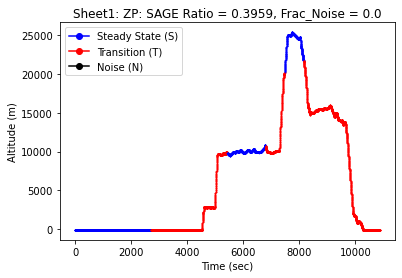

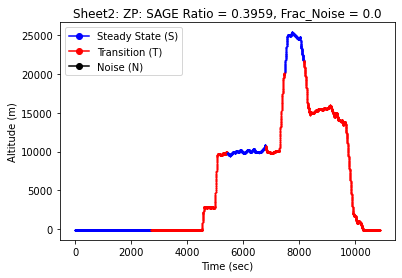

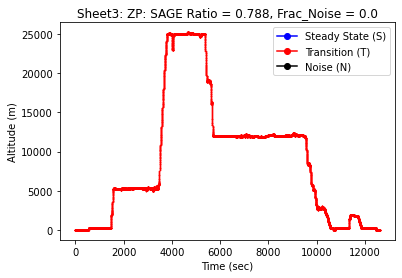

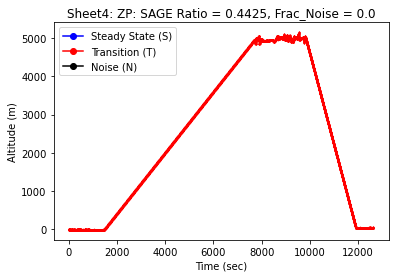

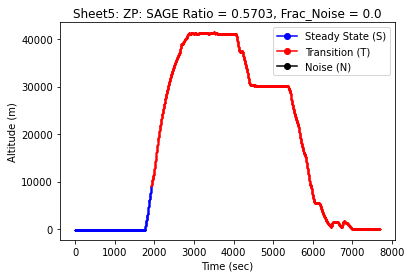

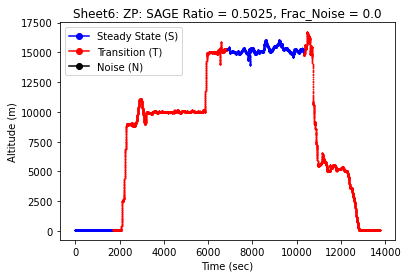

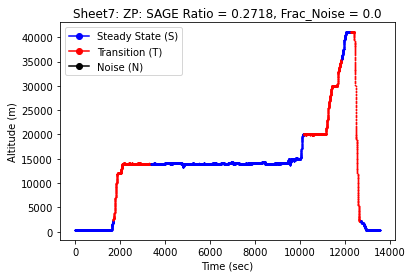

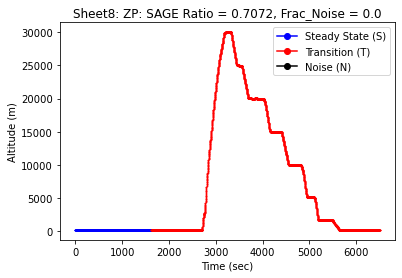

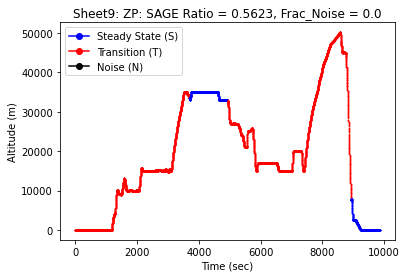

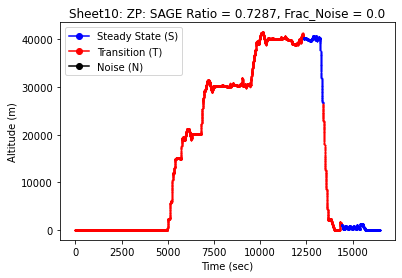

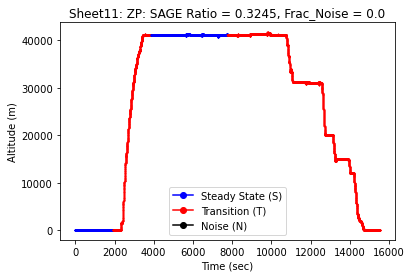

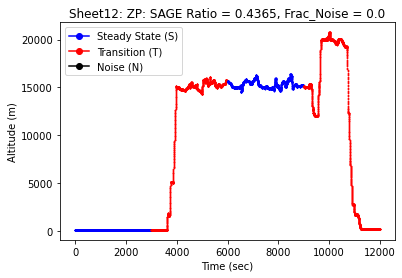

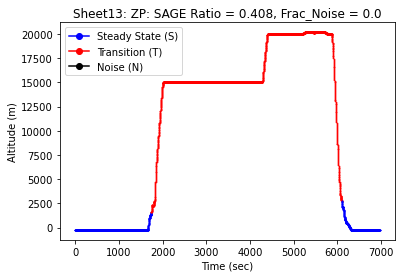

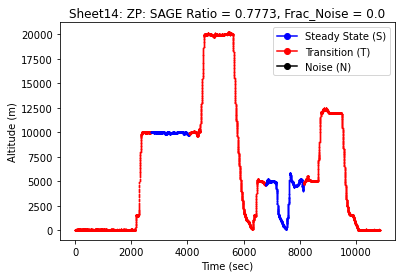

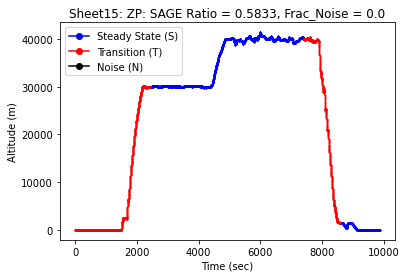

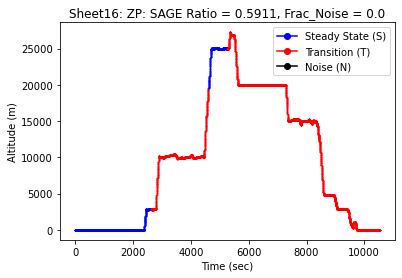

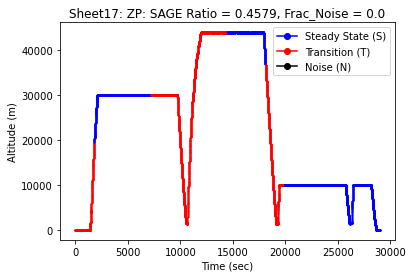

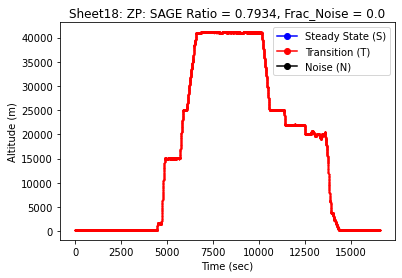

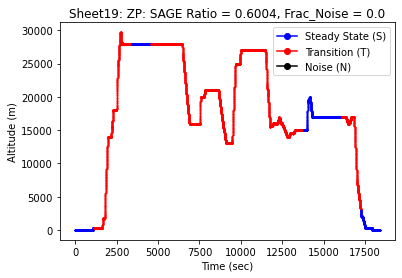

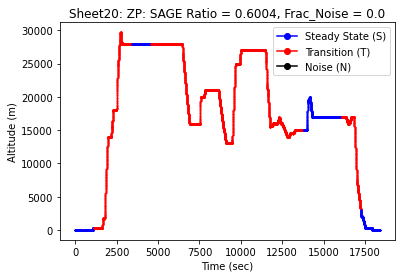

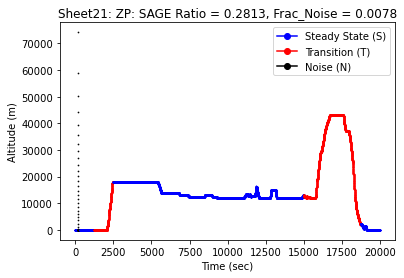

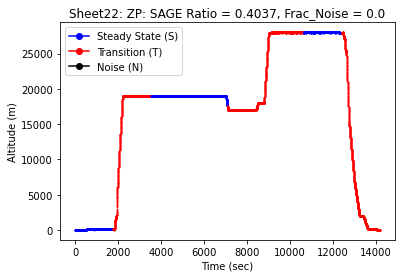

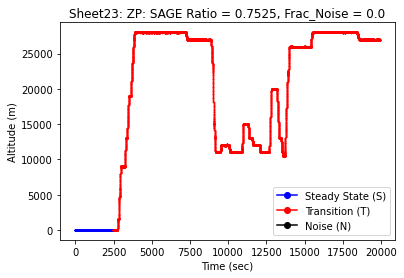

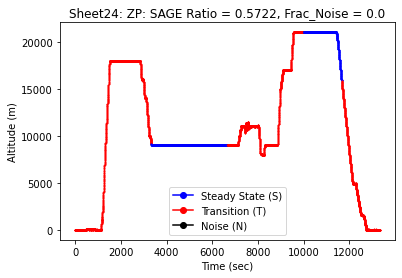

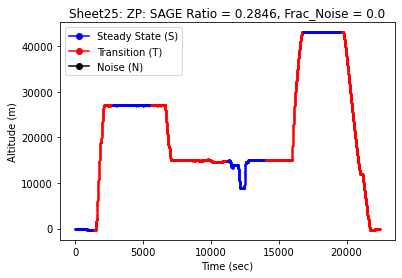

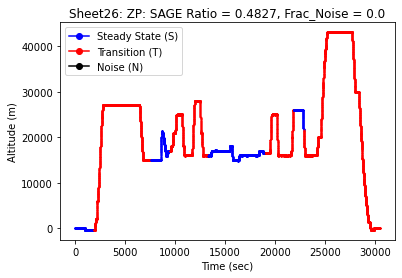

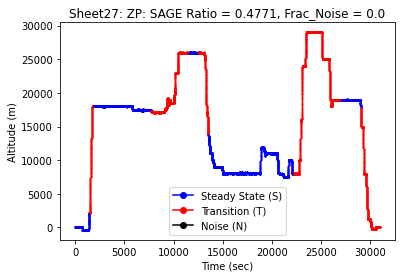

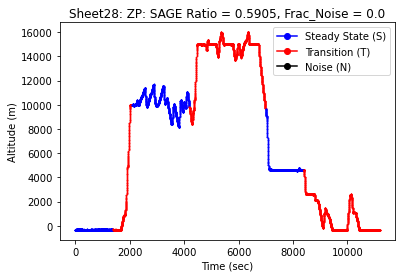

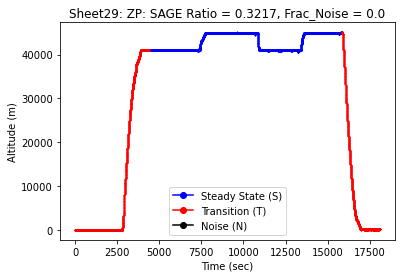

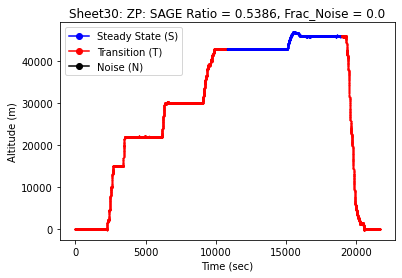

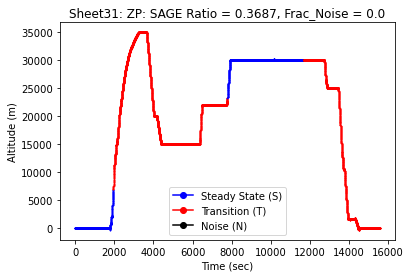

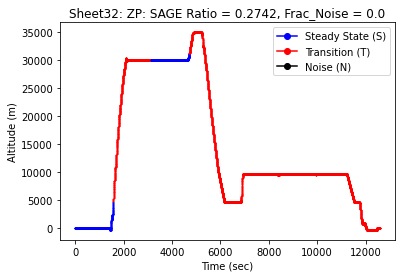

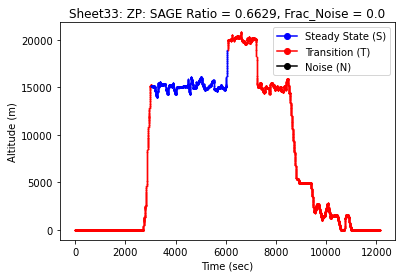

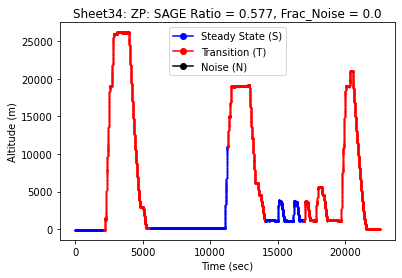

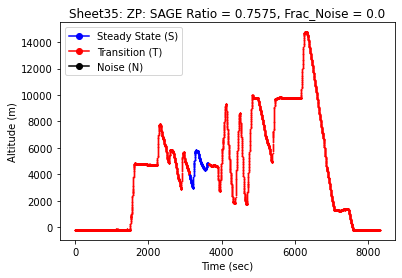

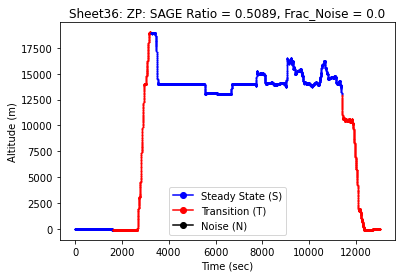

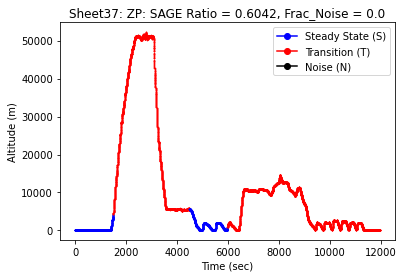

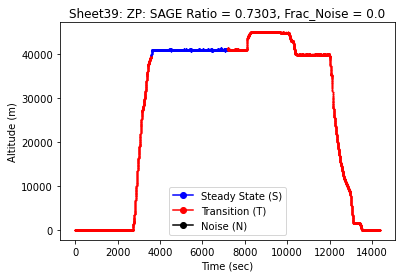

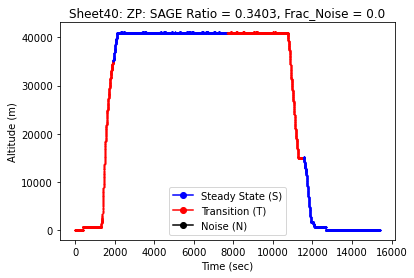

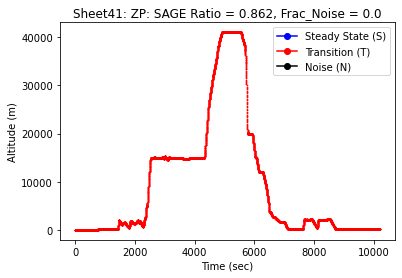

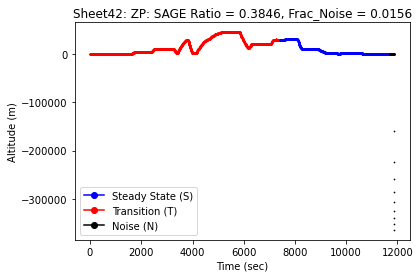

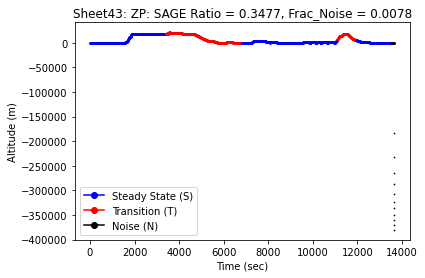

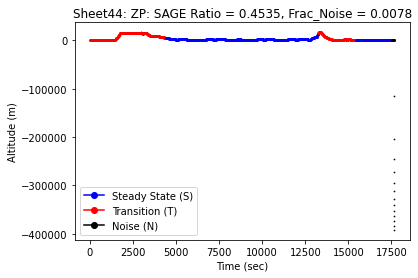

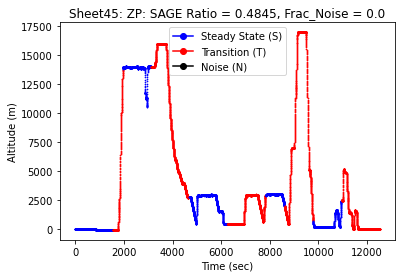

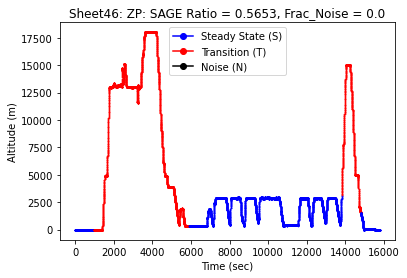

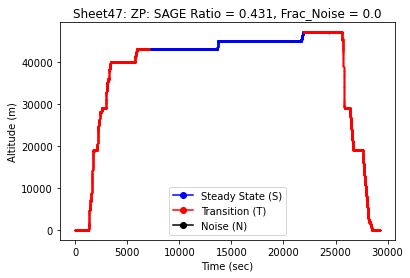

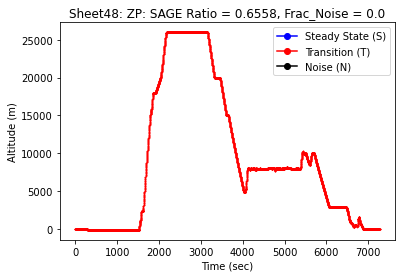

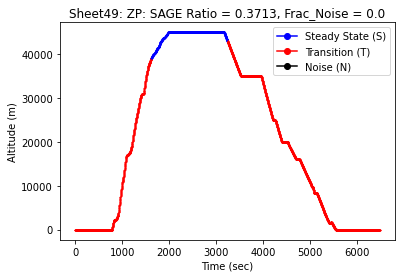

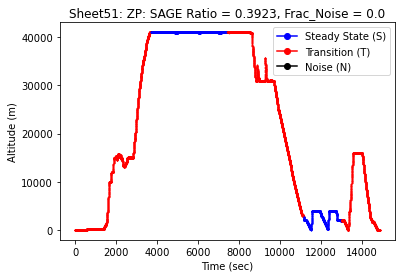

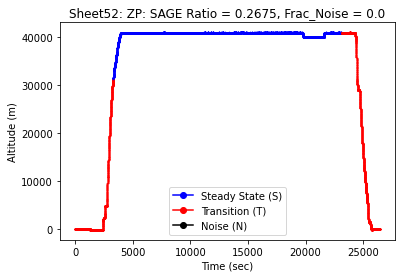

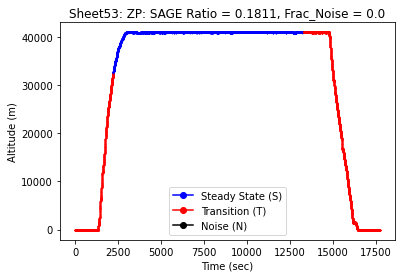

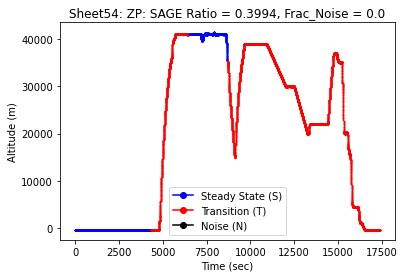

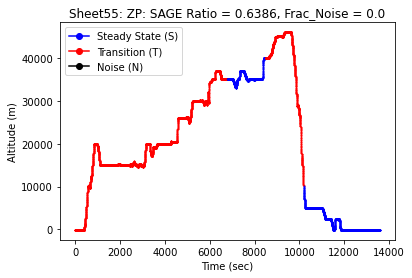

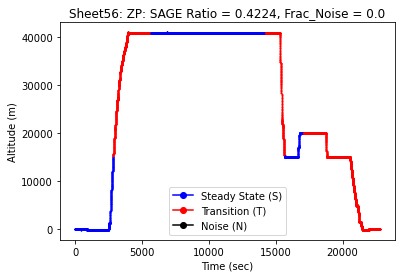

In [5]:
# Optimal parameter values obtained manually by observing the plots
frac_zp = [0.035, 0.035, 0.087, 0.061, 0.061, 0.061, 0.035, 0.087, 0.035, 0.035, 0.035, 0.087, 0.061, 0.087, 0.035, \
           0.035, 0.061, 0.087, 0.035, 0.035, 0.061, 0.061, 0.087, 0.087, 0.061, 0.035, 0.035, 0.035, 0.087, 0.061, \
           0.035, 0.061, 0.087, 0.035, 0.061, 0.061, 0.061, 0.061, 0.061, 0.061, 0.138, 0.035, 0.061, 0.061, 0.035, \
           0.061, 0.087, 0.061, 0.035, 0.035, 0.035, 0.061, 0.035, 0.061, 0.061, 0.035]

opt_fracs = {'ZP': frac_zp}

col_names = ['ZP']
sage_ratio, fracnoise = dict(), dict()
for col in col_names:
    sage_ratio[col] = []
    fracnoise[col] = []

for sheet_ind, sheet_name in enumerate(sheet_to_df_map): 
    if sheet_ind == 37 or sheet_ind == 49: # Data for these project IDs is missing
        continue
    df = sheet_to_df_map[sheet_name]
    for col_ind, col in enumerate(col_names):        
        process_data = df[col].dropna().to_numpy()
        len_data = process_data.shape[0]
        
        if len_data == 0:
            sage_ratio[col].append(-1)
            fracnoise[col].append(-1)
            continue
            
        err_data = np.var(process_data)
        
        model = Modified_Interval_Halving(noise_err = opt_fracs[col][sheet_ind]*err_data, ylabel = 'Altitude (m)', \
                                          min_window_len = 100, title = str(sheet_name + ": " + col), suppress_print = True)

        model.train_model(process_data)        
        fig_plot = plt.figure()
        model.plot_data_intervals()
        plt.show()
        sage_ratio[col].append(model.scaled_avg_global_err()/(opt_fracs[col][sheet_ind]*err_data))
        fracnoise[col].append(model.frac_noise())

## Parameters for finding anomalous time series
## 1) SAGE Ratio = SAGE/NoiseError
## 2) Frac_Noise = Length of Noisy Intervals/Total Length of Time Series

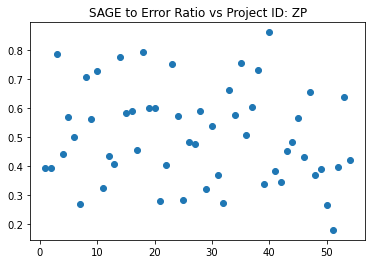

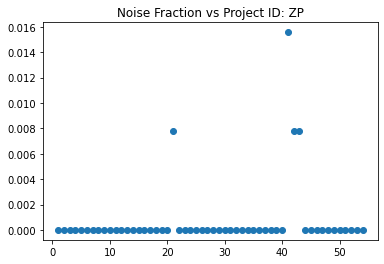

In [6]:
for col in ['ZP']:
    plt.figure()
    plt.scatter(np.arange(1, len(sage_ratio[col])+1), np.array(sage_ratio[col]))
    plt.title('SAGE to Error Ratio vs Project ID: {}'.format(col))
    plt.show()

for col in ['ZP']:
    plt.figure()
    plt.scatter(np.arange(1, len(fracnoise[col])+1), np.array(fracnoise[col]))
    plt.title('Noise Fraction vs Project ID: {}'.format(col))
    plt.show()